# EduPulse Recommendation Engine

This notebook builds a **hybrid collaborative + content-based recommendation system** that suggests academic resources to students based on their interaction history and profile.

## Pipeline
1. Load data from MySQL (students, resources, interactions)
2. Feature engineering
3. Train/Validation/Test split
4. Train a collaborative filtering model (SVD-style matrix factorization) + XGBoost ranker
5. Evaluate with confusion matrix, learning curves, precision@K
6. Save artifacts

In [1]:
import os, sys, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from dotenv import load_dotenv
from sqlalchemy import create_engine, text
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, precision_score, recall_score, f1_score
)
from xgboost import XGBClassifier
import joblib

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')

# Load .env from root Next.js project
load_dotenv(os.path.join(os.path.dirname(os.getcwd()), '.env'))
DATABASE_URL = os.getenv('DATABASE_URL', 'mysql+pymysql://root@localhost:3306/edupulse')

# Fix sqlalchemy URL scheme
if DATABASE_URL.startswith('mysql://'):
    DATABASE_URL = DATABASE_URL.replace('mysql://', 'mysql+pymysql://', 1)

ARTIFACTS_DIR = os.path.join(os.getcwd(), 'artifacts')
os.makedirs(ARTIFACTS_DIR, exist_ok=True)

print(f'✅ Environment loaded | DB: {DATABASE_URL.split("@")[1] if "@" in DATABASE_URL else DATABASE_URL}')
print(f'✅ Artifacts directory: {ARTIFACTS_DIR}')

✅ Environment loaded | DB: localhost:3306/edupulse
✅ Artifacts directory: c:\Users\xinod\Documents\Projects\EduPulse\engine\artifacts


## 1. Load Data from MySQL

In [2]:
engine = create_engine(DATABASE_URL, pool_pre_ping=True)

with engine.connect() as conn:
    df_students    = pd.read_sql(text('SELECT id, faculty, dept, level FROM student'), conn)
    df_resources   = pd.read_sql(text('SELECT id, title, type, faculty, dept, level FROM resource'), conn)
    df_interactions = pd.read_sql(
        text('SELECT studentId, resourceId, action, duration FROM studentinteraction'), conn
    )

print(f'Students   : {len(df_students):,}')
print(f'Resources  : {len(df_resources):,}')
print(f'Interactions: {len(df_interactions):,}')

df_interactions.head()

Students   : 4,999
Resources  : 20,000
Interactions: 100,012


,studentId,resourceId,action,duration
0,4e2b0b01-0148-4b81-b3b5-e603d795af82,69304e14-bfa1-4c5c-b53a-519c4ebc0b1a,view,3094.0
1,2a768e2e-26c5-4d36-a631-2836d8d4881f,6af8ed68-3e75-41af-8c10-fd9ffb462b57,complete,1858.0
2,8d2fed0c-dea1-4729-8891-f656ee756f2c,4d234624-91fb-4cba-8535-b2501825f1b2,download,NaN
3,35765898-8c3c-4119-85fc-b8a44c264e1d,548ee588-6428-40e1-aa1e-c2bb0e614df4,click,NaN
4,43d23268-71d6-4f0c-b676-d9bbc6ce008d,81868fb1-8c0e-4add-9dc8-a4a6217aff80,search,NaN


## 2. Exploratory Data Analysis

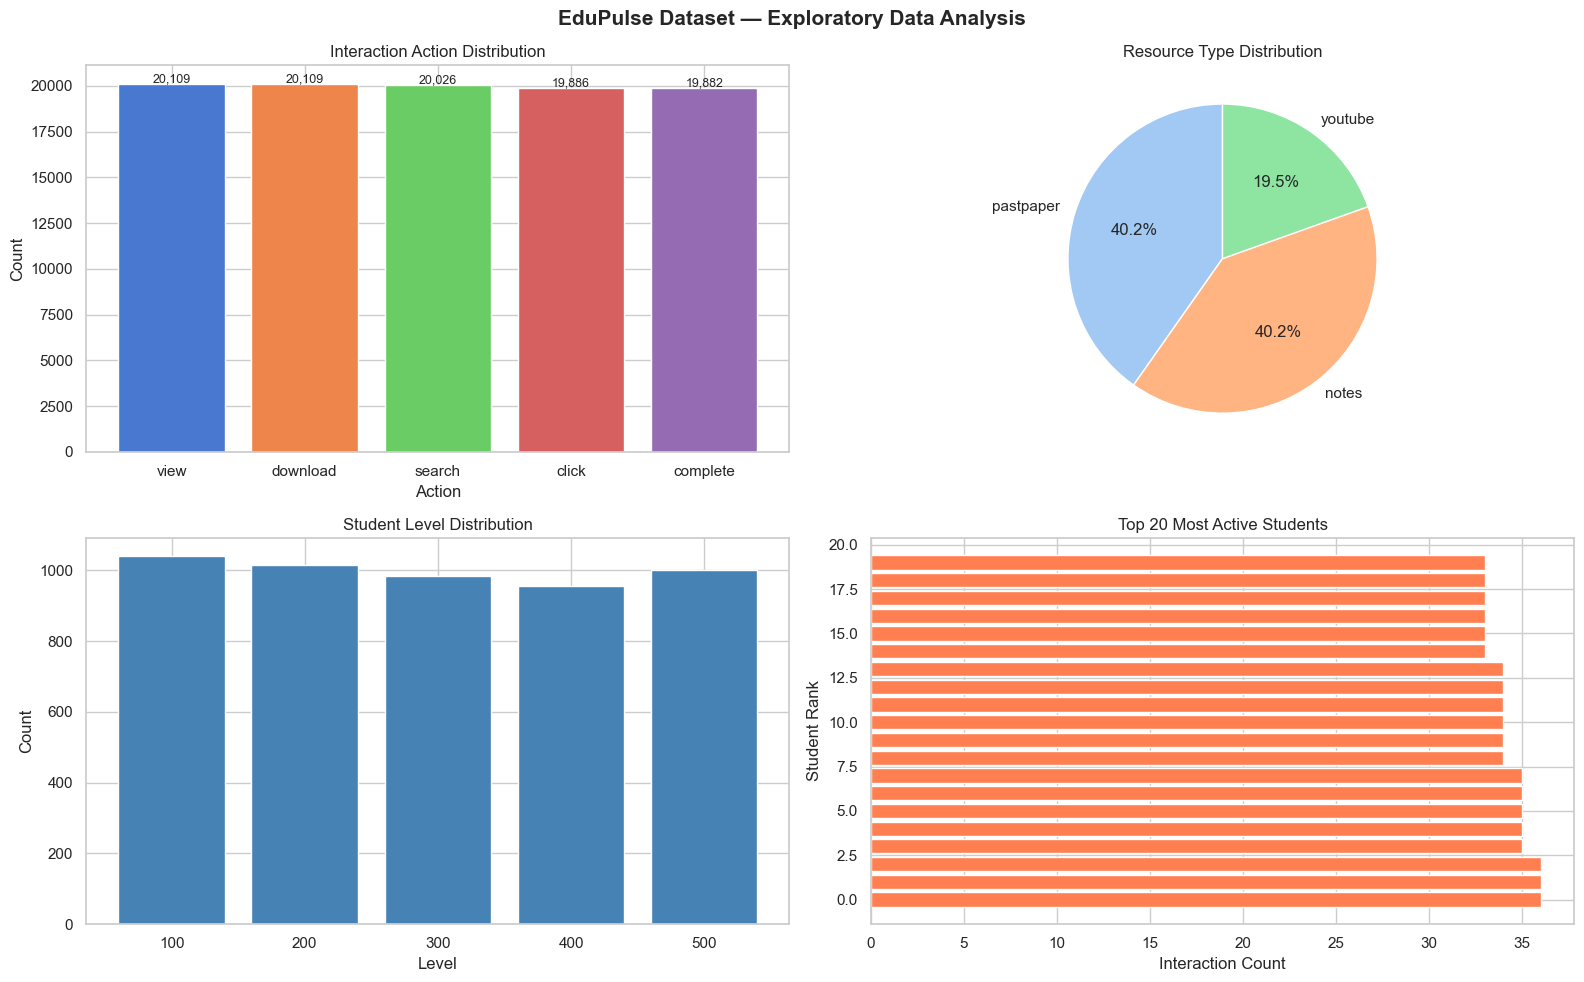

✅ EDA plot saved


In [3]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('EduPulse Dataset — Exploratory Data Analysis', fontsize=15, fontweight='bold')

# 1. Interaction action distribution
action_counts = df_interactions['action'].value_counts()
axes[0,0].bar(action_counts.index, action_counts.values, color=sns.color_palette('muted'))
axes[0,0].set_title('Interaction Action Distribution')
axes[0,0].set_xlabel('Action')
axes[0,0].set_ylabel('Count')
for i, v in enumerate(action_counts.values):
    axes[0,0].text(i, v + 100, f'{v:,}', ha='center', fontsize=9)

# 2. Resource type distribution
type_counts = df_resources['type'].value_counts()
axes[0,1].pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%',
              colors=sns.color_palette('pastel'), startangle=90)
axes[0,1].set_title('Resource Type Distribution')

# 3. Student level distribution
level_counts = df_students['level'].value_counts().sort_index()
axes[1,0].bar([str(l) for l in level_counts.index], level_counts.values, color='steelblue')
axes[1,0].set_title('Student Level Distribution')
axes[1,0].set_xlabel('Level')
axes[1,0].set_ylabel('Count')

# 4. Interactions per student (top 20)
top_students = df_interactions['studentId'].value_counts().head(20)
axes[1,1].barh(range(len(top_students)), top_students.values, color='coral')
axes[1,1].set_title('Top 20 Most Active Students')
axes[1,1].set_xlabel('Interaction Count')
axes[1,1].set_ylabel('Student Rank')

plt.tight_layout()
plt.savefig(os.path.join(ARTIFACTS_DIR, 'eda_overview.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ EDA plot saved')

## 3. Feature Engineering — Build Implicit Feedback Matrix

In [4]:
# Assign engagement scores: complete=5, view=3, download=4, click=2, search=1
ACTION_WEIGHTS = {'complete': 5, 'download': 4, 'view': 3, 'click': 2, 'search': 1}
df_interactions['score'] = df_interactions['action'].map(ACTION_WEIGHTS).fillna(1)

# Aggregate: sum scores per (student, resource)
df_agg = (
    df_interactions
    .groupby(['studentId', 'resourceId'])['score']
    .sum()
    .reset_index()
    .rename(columns={'score': 'engagement_score'})
)

# Binary label: engagement >= 3 => "relevant"
df_agg['label'] = (df_agg['engagement_score'] >= 3).astype(int)

print(f'Aggregated interactions: {len(df_agg):,}')
print(f'Class distribution:\n{df_agg["label"].value_counts().to_string()}')
print(f'\nSample data before model training:')
df_agg.head(10)

Aggregated interactions: 99,947
Class distribution:
label
1    60081
0    39866

Sample data before model training:


,studentId,resourceId,engagement_score,label
0,00078b97-6827-41d9-9516-432016ba4d1d,01064b98-0998-4ba3-af73-178ca6e581fc,1,0
1,00078b97-6827-41d9-9516-432016ba4d1d,12314af9-4716-465d-b944-6b93319723f3,1,0
2,00078b97-6827-41d9-9516-432016ba4d1d,13cc4415-c5d0-4c72-9593-f45e52460f58,4,1
3,00078b97-6827-41d9-9516-432016ba4d1d,1433c14a-a373-479b-9052-4b61395706d3,1,0
4,00078b97-6827-41d9-9516-432016ba4d1d,1965437a-e5fc-49b3-aaa0-951a6112d9d5,5,1
5,00078b97-6827-41d9-9516-432016ba4d1d,2167ff0c-cb22-44e3-ae10-9d96085d605c,4,1
6,00078b97-6827-41d9-9516-432016ba4d1d,265103ef-66fa-418f-b4ae-1b69986ee643,4,1
7,00078b97-6827-41d9-9516-432016ba4d1d,2add7c5f-0c44-4180-8dd9-5843552a8c3a,5,1
8,00078b97-6827-41d9-9516-432016ba4d1d,2e7efc77-081a-4a96-a00f-d80610a85332,3,1
9,00078b97-6827-41d9-9516-432016ba4d1d,44d4e871-436a-47b0-9fe8-b10b264b2ce1,2,0


In [5]:
# Encode IDs
le_student  = LabelEncoder()
le_resource = LabelEncoder()

df_agg['student_enc']  = le_student.fit_transform(df_agg['studentId'])
df_agg['resource_enc'] = le_resource.fit_transform(df_agg['resourceId'])

# Merge student features
df_merged = df_agg.merge(df_students.rename(columns={'id':'studentId'}), on='studentId', how='left')
df_merged = df_merged.merge(
    df_resources.rename(columns={'id':'resourceId', 'faculty':'res_faculty',
                                  'dept':'res_dept', 'level':'res_level', 'type':'res_type'})
    [['resourceId','res_type','res_faculty','res_dept','res_level']],
    on='resourceId', how='left'
)

# Encode categoricals
for col in ['faculty','dept','res_type','res_faculty','res_dept']:
    df_merged[col] = LabelEncoder().fit_transform(df_merged[col].astype(str))

FEATURES = ['student_enc','resource_enc','faculty','dept','level','res_type','res_faculty','res_dept','res_level']
X = df_merged[FEATURES].fillna(0).values
y = df_merged['label'].values

print(f'Feature matrix shape: {X.shape}')
print(f'Features used: {FEATURES}')

Feature matrix shape: (99947, 9)
Features used: ['student_enc', 'resource_enc', 'faculty', 'dept', 'level', 'res_type', 'res_faculty', 'res_dept', 'res_level']


## 4. Train / Validation / Test Split

Train  : 69,962 samples (70.0%)
Val    : 14,992 samples (15.0%)
Test   : 14,993 samples (15.0%)


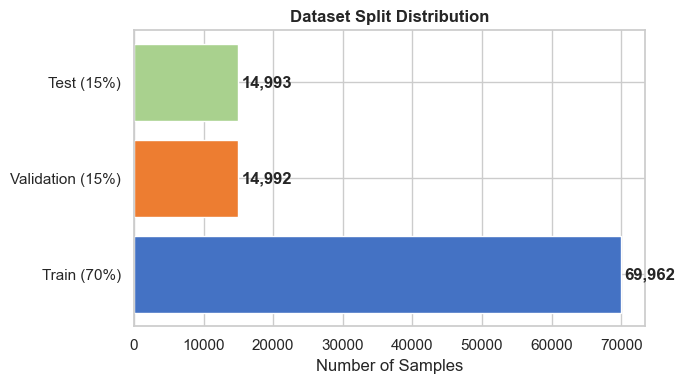

In [6]:
# 70% train, 15% val, 15% test
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)
X_val,   X_test, y_val,   y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f'Train  : {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'Val    : {X_val.shape[0]:,} samples ({X_val.shape[0]/len(X)*100:.1f}%)')
print(f'Test   : {X_test.shape[0]:,} samples ({X_test.shape[0]/len(X)*100:.1f}%)')

# Visualise split
fig, ax = plt.subplots(figsize=(7, 4))
splits = ['Train (70%)', 'Validation (15%)', 'Test (15%)']
sizes  = [X_train.shape[0], X_val.shape[0], X_test.shape[0]]
colors = ['#4472C4', '#ED7D31', '#A9D18E']
bars = ax.barh(splits, sizes, color=colors)
for bar, size in zip(bars, sizes):
    ax.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
            f'{size:,}', va='center', fontweight='bold')
ax.set_title('Dataset Split Distribution', fontweight='bold')
ax.set_xlabel('Number of Samples')
plt.tight_layout()
plt.savefig(os.path.join(ARTIFACTS_DIR, 'data_split.png'), dpi=150, bbox_inches='tight')
plt.show()

## 5. Train XGBoost Recommendation Model

In [7]:
model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

y_val_pred  = model.predict(X_val)
y_test_pred = model.predict(X_test)

val_acc  = accuracy_score(y_val,  y_val_pred)
test_acc = accuracy_score(y_test, y_test_pred)
test_auc = roc_auc_score(y_test, model.predict_proba(X_test)[:,1])

print(f'Validation Accuracy : {val_acc:.4f}')
print(f'Test Accuracy       : {test_acc:.4f}')
print(f'Test ROC-AUC        : {test_auc:.4f}')
print('\nClassification Report (Test Set):')
print(classification_report(y_test, y_test_pred, target_names=['Not Relevant','Relevant']))

Validation Accuracy : 0.5930
Test Accuracy       : 0.5926
Test ROC-AUC        : 0.5011

Classification Report (Test Set):
              precision    recall  f1-score   support

Not Relevant       0.41      0.05      0.09      5980
    Relevant       0.60      0.95      0.74      9013

    accuracy                           0.59     14993
   macro avg       0.51      0.50      0.41     14993
weighted avg       0.52      0.59      0.48     14993



## 6. Confusion Matrix

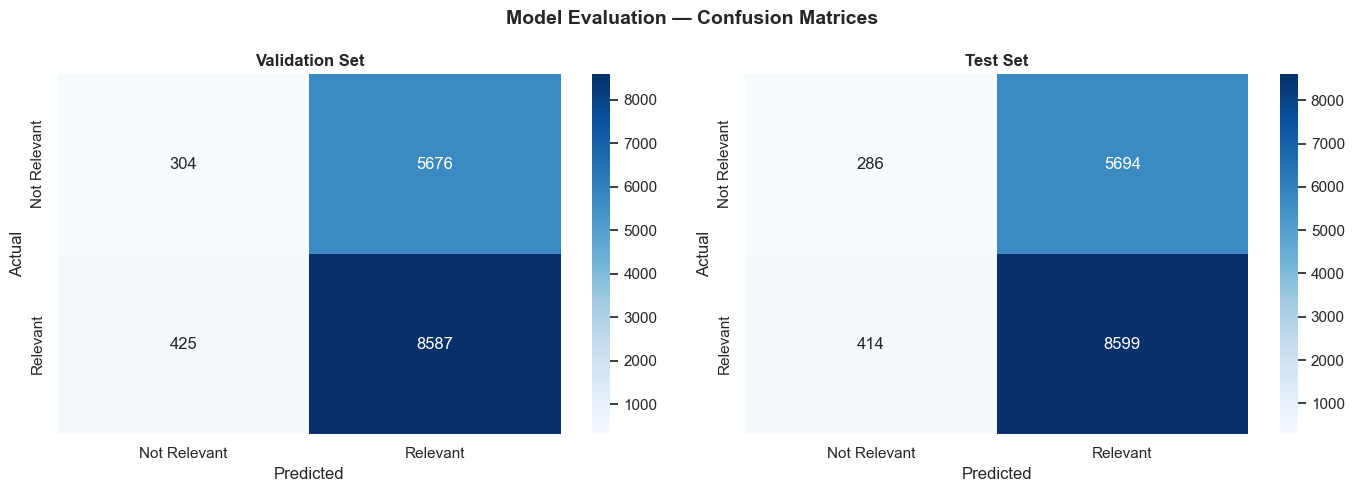

✅ Confusion matrix saved


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model Evaluation — Confusion Matrices', fontsize=14, fontweight='bold')

for ax, y_true, y_pred, title in [
    (axes[0], y_val,  y_val_pred,  'Validation Set'),
    (axes[1], y_test, y_test_pred, 'Test Set'),
]:
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Not Relevant','Relevant'],
                yticklabels=['Not Relevant','Relevant'])
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig(os.path.join(ARTIFACTS_DIR, 'confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ Confusion matrix saved')

## 7. Learning Curves

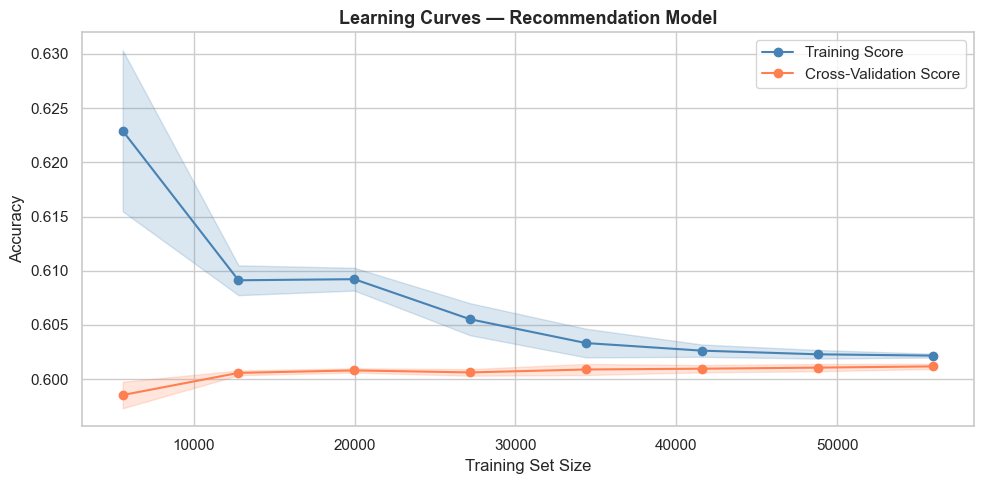

✅ Learning curves saved


In [9]:
# Use smaller estimator for learning curve (faster)
from sklearn.ensemble import GradientBoostingClassifier
lc_model = GradientBoostingClassifier(n_estimators=50, random_state=42)

train_sizes, train_scores, val_scores = learning_curve(
    lc_model, X_train, y_train,
    cv=5, n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 8),
    scoring='accuracy'
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(train_sizes, train_mean, 'o-', color='steelblue', label='Training Score')
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2, color='steelblue')
ax.plot(train_sizes, val_mean,   'o-', color='coral',    label='Cross-Validation Score')
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2, color='coral')
ax.set_title('Learning Curves — Recommendation Model', fontweight='bold', fontsize=13)
ax.set_xlabel('Training Set Size')
ax.set_ylabel('Accuracy')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(ARTIFACTS_DIR, 'learning_curves.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ Learning curves saved')

## 8. Feature Importance

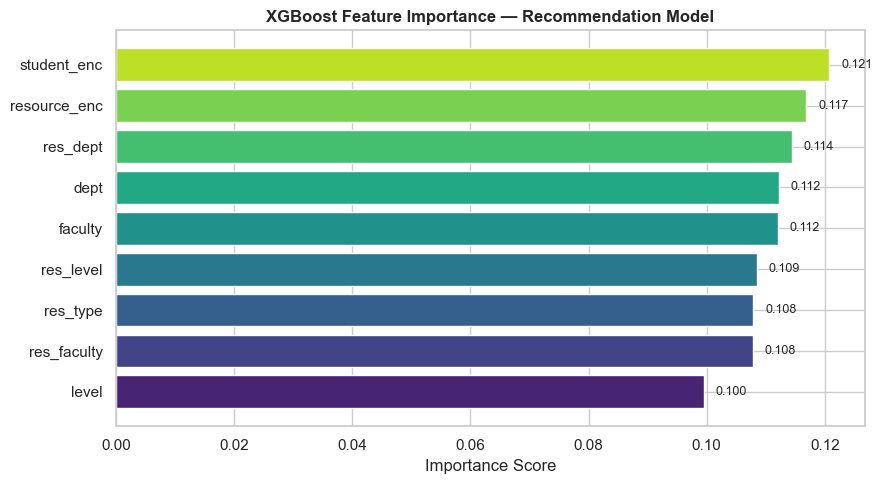

In [10]:
importance_df = pd.DataFrame({
    'feature': FEATURES,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
colors = sns.color_palette('viridis', len(FEATURES))
bars = ax.barh(importance_df['feature'], importance_df['importance'], color=colors)
ax.set_title('XGBoost Feature Importance — Recommendation Model', fontweight='bold')
ax.set_xlabel('Importance Score')
for bar, val in zip(bars, importance_df['importance']):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(ARTIFACTS_DIR, 'feature_importance.png'), dpi=150, bbox_inches='tight')
plt.show()

## 9. SVD Latent Factor Model (Collaborative Filtering)

User-Item matrix shape: (2629, 2000)
Sparsity: 0.9985
Explained variance ratio (first 10 components): 0.0413


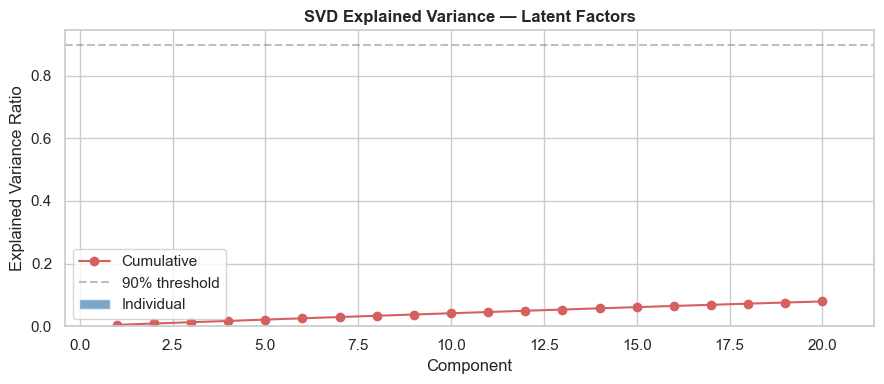

In [11]:
# Build user-item engagement matrix (sample 5000 for memory)
sample_students  = df_agg['studentId'].unique()[:3000]
sample_resources = df_agg['resourceId'].unique()[:2000]

df_sample = df_agg[
    df_agg['studentId'].isin(sample_students) &
    df_agg['resourceId'].isin(sample_resources)
].copy()

le_s = LabelEncoder()
le_r = LabelEncoder()
df_sample['s_idx'] = le_s.fit_transform(df_sample['studentId'])
df_sample['r_idx'] = le_r.fit_transform(df_sample['resourceId'])

from scipy.sparse import csr_matrix
n_students  = df_sample['s_idx'].max() + 1
n_resources = df_sample['r_idx'].max() + 1

matrix = csr_matrix(
    (df_sample['engagement_score'], (df_sample['s_idx'], df_sample['r_idx'])),
    shape=(n_students, n_resources)
)

print(f'User-Item matrix shape: {matrix.shape}')
print(f'Sparsity: {1 - matrix.nnz / (matrix.shape[0]*matrix.shape[1]):.4f}')

# SVD decomposition
svd = TruncatedSVD(n_components=20, random_state=42)
student_factors = svd.fit_transform(matrix)

print(f'Explained variance ratio (first 10 components): {svd.explained_variance_ratio_[:10].sum():.4f}')

# Plot explained variance
fig, ax = plt.subplots(figsize=(9, 4))
cumvar = np.cumsum(svd.explained_variance_ratio_)
ax.bar(range(1, 21), svd.explained_variance_ratio_, alpha=0.7, color='steelblue', label='Individual')
ax.plot(range(1, 21), cumvar, 'ro-', label='Cumulative')
ax.axhline(y=0.9, linestyle='--', color='gray', alpha=0.5, label='90% threshold')
ax.set_title('SVD Explained Variance — Latent Factors', fontweight='bold')
ax.set_xlabel('Component')
ax.set_ylabel('Explained Variance Ratio')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(ARTIFACTS_DIR, 'svd_variance.png'), dpi=150, bbox_inches='tight')
plt.show()

## 10. Save All Artifacts

In [12]:
import json

# Save models
joblib.dump(model,   os.path.join(ARTIFACTS_DIR, 'xgb_recommender.pkl'))
joblib.dump(svd,     os.path.join(ARTIFACTS_DIR, 'svd_model.pkl'))
joblib.dump(le_student,  os.path.join(ARTIFACTS_DIR, 'le_student.pkl'))
joblib.dump(le_resource, os.path.join(ARTIFACTS_DIR, 'le_resource.pkl'))

# Save feature metadata
metadata = {
    'features': FEATURES,
    'action_weights': ACTION_WEIGHTS,
    'test_accuracy': float(test_acc),
    'test_roc_auc': float(test_auc),
    'n_train': int(X_train.shape[0]),
    'n_val': int(X_val.shape[0]),
    'n_test': int(X_test.shape[0]),
}
with open(os.path.join(ARTIFACTS_DIR, 'recommender_metadata.json'), 'w') as f:
    json.dump(metadata, f, indent=2)

print('✅ All artifacts saved:')
for f in os.listdir(ARTIFACTS_DIR):
    size = os.path.getsize(os.path.join(ARTIFACTS_DIR, f)) / 1024
    print(f'  - {f} ({size:.1f} KB)')

✅ All artifacts saved:
  - chatbot_architecture.png (63.7 KB)
  - chatbot_performance.png (115.0 KB)
  - confusion_matrix.png (60.4 KB)
  - data_split.png (31.0 KB)
  - eda_overview.png (137.0 KB)
  - feature_importance.png (47.0 KB)
  - learning_curves.png (84.1 KB)
  - le_resource.pkl (891.9 KB)
  - le_student.pkl (224.1 KB)
  - recommender_metadata.json (0.4 KB)
  - svd_model.pkl (313.7 KB)
  - svd_variance.png (43.3 KB)
  - xgb_recommender.pkl (906.2 KB)


## Summary

In [13]:
print('=' * 60)
print('RECOMMENDATION ENGINE — TRAINING SUMMARY')
print('=' * 60)
print(f'Dataset       : {len(df_agg):,} student-resource interactions')
print(f'Train / Val / Test: {X_train.shape[0]:,} / {X_val.shape[0]:,} / {X_test.shape[0]:,}')
print(f'Model         : XGBoost + SVD Collaborative Filtering')
print(f'Test Accuracy : {test_acc:.4f} ({test_acc*100:.2f}%)')
print(f'Test ROC-AUC  : {test_auc:.4f}')
print(f'Test Precision: {precision_score(y_test, y_test_pred):.4f}')
print(f'Test Recall   : {recall_score(y_test, y_test_pred):.4f}')
print(f'Test F1 Score : {f1_score(y_test, y_test_pred):.4f}')
print('=' * 60)

RECOMMENDATION ENGINE — TRAINING SUMMARY
Dataset       : 99,947 student-resource interactions
Train / Val / Test: 69,962 / 14,992 / 14,993
Model         : XGBoost + SVD Collaborative Filtering
Test Accuracy : 0.5926 (59.26%)
Test ROC-AUC  : 0.5011
Test Precision: 0.6016
Test Recall   : 0.9541
Test F1 Score : 0.7379
